In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LIBRARIES

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import NASNetLarge
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


INPUTS

In [9]:
IMG_SIZE =(331, 331)
IMG_HEIGHT = 331
IMG_WIDTH = 331
IMG_CHANNELS=3
CLASS_NAMES=["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [10]:
train_dir ="/content/drive/MyDrive/flower_images/train"
val_dir ="/content/drive/MyDrive/flower_images/val"

train_datagen = ImageDataGenerator(
    rotation_range=20,
    rescale =(1./255),
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale = 1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = 16,
    class_mode ='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = IMG_SIZE,
    batch_size = 16,
    class_mode ='categorical'
)

Found 3000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.


NETWORK ARCHITECTURE

In [11]:
base_model = NASNetLarge(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(CLASS_NAMES), activation='softmax')(x)

model = Model(inputs= base_model.input, outputs=predictions)



In [12]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics =['accuracy']
)

history = model.fit(
    train_generator,
    validation_data= val_generator,
    epochs =3,
)

Epoch 1/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 1109s 6s/step - accuracy: 0.7357 - loss: 0.7229 - val_accuracy: 0.8400 - val_loss: 0.4370
Epoch 2/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 140s 743ms/step - accuracy: 0.8427 - loss: 0.4155 - val_accuracy: 0.8690 - val_loss: 0.3741
Epoch 3/3
188/188 ━━━━━━━━━━━━━━━━━━━━ 139s 738ms/step - accuracy: 0.8853 - loss: 0.3007 - val_accuracy: 0.8760 - val_loss: 0.3514


PLOTTING

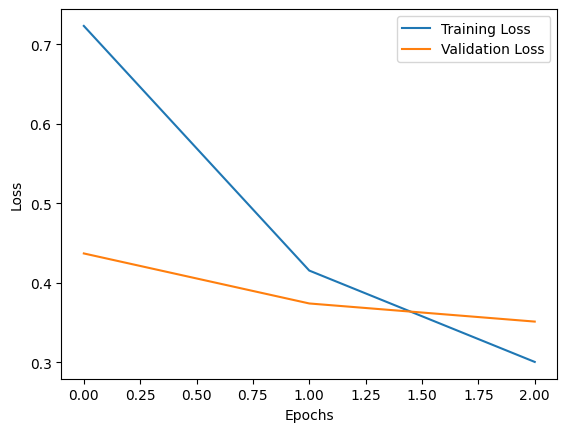

In [15]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

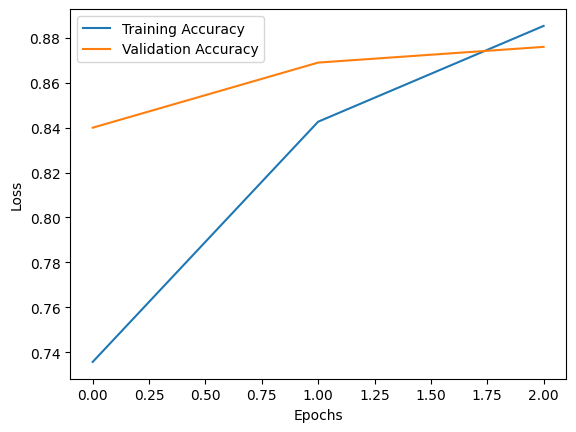

In [17]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()